In [154]:
from collections import defaultdict, Counter

import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import random
import math

plt.style.use("dark_background")

We test bigram and trigram approaches for next word prediction in the Penn-Treebank dataset, which contains snippets from the Wall Street Journal. In this data set, there contains `<unk>` which denotes an unknown word.

In [132]:
bigram = defaultdict(Counter)
trigram = defaultdict(Counter)

In [133]:
with open("../data/penn-treebank/ptb.train.txt") as f:
    for line in f:
        words = line.strip().split()
        tokens = ["<s>", "<s>"] + words + ["</s>"]

        for i in range(len(tokens)):
            if i >= 1: bigram[tokens[i-1]][tokens[i]] += 1
            if i>= 2: trigram[(tokens[i-2], tokens[i-1])][tokens[i]] += 1

The tokens `<s>` and `</s>` are used to denote the start and end of a sentence, delimited by a newline in the data. Two `<s>` tokens are required for a trigram, which interprets the third word as the first word of a sentence with two prior words being the start of the sentence.

In [134]:
def sample_bigram(w1):
    counts = bigram[w1]

    if not counts: return "</s>"

    words = list(counts.keys())
    weights = list(counts.values())

    # return a random choice weighted by the number of times it showed up in the training set
    return random.choices(words, weights=weights, k=1)[0]

def sample_trigram(w1, w2):
    counts = trigram[(w1, w2)]

    if not counts: return "</s>"

    words = list(counts.keys())
    weights = list(counts.values())

    return random.choices(words, weights=weights, k=1)[0]

We can now do something fairly interesting - generate a completely random sentence with bigrams and trigrams. Of course, our sentences are derived from financial news, and so we should expect words relating to financial markets. 

We can do this by starting with `<s>` and `<s> <s>` for bigram and trigram respectively and then sampling from the counters.

In [135]:
word = "<s>"
sentence = []
for i in range(1, 50):
    word = sample_bigram(word)
    sentence.append(word)

    if word == "</s>": break

print(' '.join(sentence))

it </s>


In [136]:
word_1 = "<s>"
word_2 = "<s>"
sentence = []
for i in range(1, 50):
    word_temp = sample_trigram(word_1, word_2)

    # exchange
    t = word_2
    word_2 = word_temp
    word_1 = t

    sentence.append(word_temp)

    if word_temp == "</s>": break

print(' '.join(sentence))

under any circumstances </s>


The above sentences do not really make any human sense. It almost feels as though the bigrams are too greedy and are too short-sighted, whereas the trigrams are a bit too long-sighted (most evident in the doubling of "the"). We could instead blend the probability of a word $w_n$ for the previous two words $w_{n-1}$ and $w_{n-2}$ by

$$ P(w_n | w_{n-1}, w_{n-2}) = \lambda P_{bigram}(w_n|w_{n-1}) + (1 - \lambda)P_{trigram}(w_n|w_{n-1}, w_{n-2})$$

In [137]:
def sample_blended(w1, w2, L=0.5):
    bigram_cands = bigram[w2]
    trigram_cands = trigram[(w1, w2)]

    cands = set(bigram_cands.keys()) | set(trigram_cands.keys())

    # no intersection of candidates
    if not cands: return "</s>"

    bi_total, tri_total = sum(bigram_cands.values()), sum(trigram_cands.values())
    words, weights = [], []

    for word in cands:
        p_bigram = (bigram_cands[word] / bi_total if bi_total > 0 else 0)
        p_trigram = (trigram_cands[word] / tri_total if tri_total > 0 else 0)
        p_blended = L * p_bigram + (1 - L) * p_trigram

        words.append(word)
        weights.append(p_blended)

    return random.choices(words, weights=weights, k=1)[0]

Consider the below.

In [138]:
word_1 = "<s>"
word_2 = "<s>"
sentence = []

for _ in range(50):
    word_temp = sample_blended(word_1, word_2)

    if word_temp == "</s>":
        break

    sentence.append(word_temp)

    word_1, word_2 = word_2, word_temp

print(" ".join(sentence))

tough talk about the outspoken mr. gelbart 's crackdown against her claiming among other than i ever since the N second quarter while comparable lending was dave <unk> begin <unk> problems


And the results are... much more understandable? Of course, it is not all intelligble and definitely not all valid english but some parts of it are somewhat readable. We can find the log loss of our blended model by defining
$$
\begin{align*}
    L_n &= -\log P(w_n | w_{n-1}, w_{n-2}) \\
    &= -\log \left[ \lambda P_{bigram}(w_n|w_{n-1}) + (1 - \lambda)P_{trigram}(w_n|w_{n-1}, w_{n-2}) \right]
\end{align*}
$$

In [139]:
def loss_at_n(w1, w2, word, L=0.5):
    bigram_cands = bigram[w2]
    trigram_cands = trigram[(w1, w2)]

    cands = set(bigram_cands.keys()) | set(trigram_cands.keys())

    # no intersection of candidates
    if not cands: return 0

    bi_total, tri_total = sum(bigram_cands.values()), sum(trigram_cands.values())

    p_bigram = (bigram_cands[word] / bi_total if bi_total > 0 else 0)
    p_trigram = (trigram_cands[word] / tri_total if tri_total > 0 else 0)
    return (L * p_bigram + (1 - L) * p_trigram)

In [140]:
total_loss = 0
num_predictions = 0

with open('../data/penn-treebank/ptb.test.txt') as f:
    for lines in f:
        words = line.strip().split()
        tokens = ["<s>", "<s>"] + words + ["</s>"]

        for i in range(2, len(tokens)):
            loss_i = loss_at_n(tokens[i-2], tokens[i-1], tokens[i])

            # this is kinda cheating... but WIP
            if loss_i == 0: next

            total_loss += -math.log(loss_i)
            num_predictions += 1

How do we evaluate the accuracy of a language model? A useful metric is *perplexity*, which gives a feel for how many words at each step the model is "considering", under the assumption that all words are equally likely. Essentially, it shows us how fine-graned the model is.

$$
\begin{align*}

\verb|Perplexity| &= \exp^L \\
&= \exp^{-\frac{1}{N}\sum_{t=1}^N \log P(w_t | \text{context})}

\end{align*}
$$

Another way is considering how often the model is correct. We gather this from the geometric probability. Consider some probabilities of the correct words in a sequence $\mathbf{p} = p_1, p_2, \dots, p_N$. The total probability of the sequence is 

$$ P(\verb|sequence|) = \prod_{t=1}^N p_t$$

A typical probability of getting the word correct could be derived from the geometric mean as the sequence probability is multiplicative of the per-word probability.

$$ \left(\prod_{t=1}^N p_t \right)^{1/N}$$

Through some mathematical niceties, this can actually just be calculated by doing $\exp^{-L}$.

In [141]:
average_loss = total_loss / num_predictions
print(f'Perplexity: {round(np.exp(average_loss), 3)}')
print(f'Geometric mean correctness: {round(np.exp(-average_loss), 3) * 100}%')

Perplexity: 9.372
Geometric mean correctness: 10.7%


At each step the model has ~9.4 words to guess from, which isn't great! The baseline naive model below an $n$-gram model, which would have a much lower mean correctness due to the size of the vocabulary. We could also find the optimal $\lambda$; which gives us how much to weight our model towards the bigram or the trigram. Trigrams have richer context, so it could be intuitive that we give more weight to the trigram, but we test this empirically with varying values of $\lambda$.

In [142]:
L = np.arange(0, 1.1, 0.1)
L_loss = []

for l in L:
    print(f'Testing lambda: {round(l, 2)}')
    total_loss = 0
    num_predictions = 0
    with open('../data/penn-treebank/ptb.test.txt') as f:
        for lines in f:
            words = line.strip().split()
            tokens = ["<s>", "<s>"] + words + ["</s>"]

            for i in range(2, len(tokens)):
                loss_i = loss_at_n(tokens[i-2], tokens[i-1], tokens[i], L=l)

                # this is kinda cheating... but WIP
                if loss_i == 0: next

                total_loss += -math.log(loss_i)
                num_predictions += 1

    L_loss.append({'L': l, 'average_loss': total_loss / num_predictions})

Testing lambda: 0.0
Testing lambda: 0.1
Testing lambda: 0.2
Testing lambda: 0.3
Testing lambda: 0.4
Testing lambda: 0.5
Testing lambda: 0.6
Testing lambda: 0.7
Testing lambda: 0.8
Testing lambda: 0.9
Testing lambda: 1.0


From the below - it appears that using more trigram probability is *strictly* better when compared with bigrams. This begs the question; at what $n$ does the context become dilutive of information rather than additive?

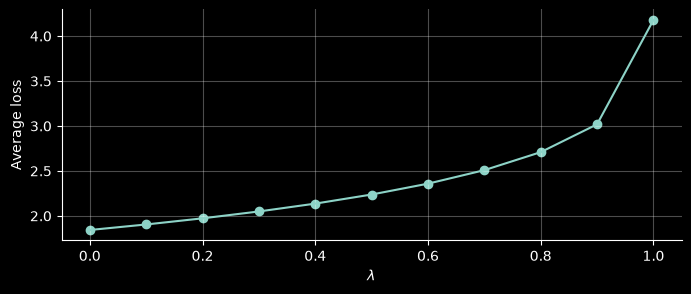

In [155]:
L_df = pd.DataFrame(L_loss)

plt.figure(figsize=(8, 3))
plt.plot(L_df['L'], L_df['average_loss'])
plt.scatter(L_df['L'], L_df['average_loss'])
plt.grid(alpha=0.3)
plt.xlabel('$\\lambda$')
plt.ylabel('Average loss')
sns.despine()

To answer this question, we consider a few more $n$-grams. We modify our loss function to accept a tuple as our input. Unlike before, we severely penalise when we do not have a case of `(words) -> next word`.

In [144]:
MIN_PROBABILITY = 1e-9
MAX_LOSS = -math.log(MIN_PROBABILITY)

def prediction_loss(counter, context, target):
    candidates = counter.get(context)

    # there hasn't been this context in training
    if not candidates: return MAX_LOSS, "unseen_context"
    # there has been this context, but the target word has never been seen
    if not candidates.get(target, 0): return MAX_LOSS, "unseen_target"

    probability = candidates[target] / sum(candidates.values())
    return -math.log(max(probability, MIN_PROBABILITY)), "observed"

def loss_at_n_tuples(counter, words, word, punish_unseen=False):
    loss, reason = prediction_loss(counter, words, word)
    return 0 if reason == "unseen_context" and not punish_unseen else loss

def evaluate_model(counter, sentences, n):
    """
    evaluate the n-gram with tracking of why a max_loss was incurred.
    """
    counts = Counter()
    losses = Counter()

    for words in sentences:
        tokens = ["<s>"] * n + words + ["</s>"]
        for i in range(n, len(tokens)):
            loss, reason = prediction_loss(counter, tuple(tokens[i-n:i]), tokens[i])
            counts[reason] += 1
            losses[reason] += loss

    total = sum(counts.values())
    seen = total - counts["unseen_context"]
    seen_loss = losses["observed"] + losses["unseen_target"]

    result = {
        "n": n,
        "num_predictions": total,
        "context_coverage": seen / total if total else float("nan"),
        "unseen_target_rate_given_context": counts["unseen_target"] / seen if seen else float("nan"),
        "average_loss": seen_loss / seen if seen else float("nan"),
        "average_loss_punish": sum(losses.values()) / total if total else float("nan"),
    }

    for reason in ("unseen_context", "unseen_target", "observed"):
        result[f"{reason}_count"] = counts[reason]
        result[f"{reason}_total_loss"] = losses[reason]
        result[f"{reason}_loss_per_token"] = losses[reason] / total if total else float("nan")
    return result


We evaluate context lengths 1 through 10 (bigrams through 11-grams). Each test token belongs to exactly one category: unseen context, known context with an unseen target continuation, or an observed context-target combination. Here, target means the actual next word in the test data, not a sampled prediction.

Zero-probability events receive a fixed maximum loss of `-log(1e-9)`, about 20.72. This is a capped-loss diagnostic, not normalized smoothing. We report loss on seen contexts, context coverage, and overall loss with both kinds of unseen event penalized.


In [159]:
ngrams = range(1, 11)
loss_at_n = []
with open("../data/penn-treebank/ptb.test.txt") as f:
    test_sentences = [line.strip().split() for line in f]

for n in ngrams:
    count = defaultdict(Counter)
    with open("../data/penn-treebank/ptb.train.txt") as f:
        for line in f:
            tokens = ["<s>"] * n + line.strip().split() + ["</s>"]
            for i in range(n, len(tokens)):
                count[tuple(tokens[i-n:i])][tokens[i]] += 1
    loss_at_n.append(evaluate_model(count, test_sentences, n))

Average capped loss on tokens with contexts observed during training. Each context length can cover a different subset of test tokens.

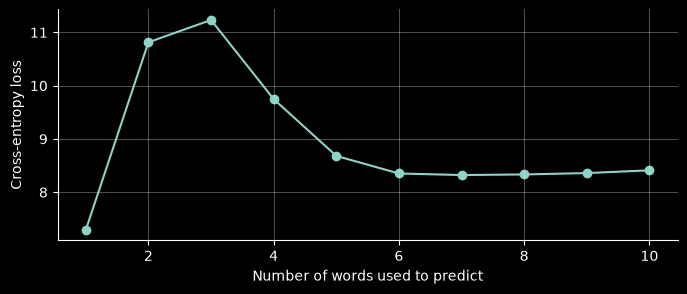

In [160]:
loss_at_n_df = pd.DataFrame(loss_at_n)

plt.figure(figsize=(8, 3))
plt.scatter(loss_at_n_df['n'], loss_at_n_df['average_loss'])
plt.plot(loss_at_n_df['n'], loss_at_n_df['average_loss'])
plt.grid(alpha=0.3)
plt.xlabel('Number of words used to predict')
plt.ylabel('Cross-entropy loss')
sns.despine()

In [161]:
loss_at_n_df = pd.DataFrame(loss_at_n)
loss_at_n_total = loss_at_n_df.copy()

The loss contributions below all use the total number of test tokens as their denominator, so they sum to the overall penalized average loss. Unseen-target events count only cases with known contexts; the two missing-event categories do not overlap.


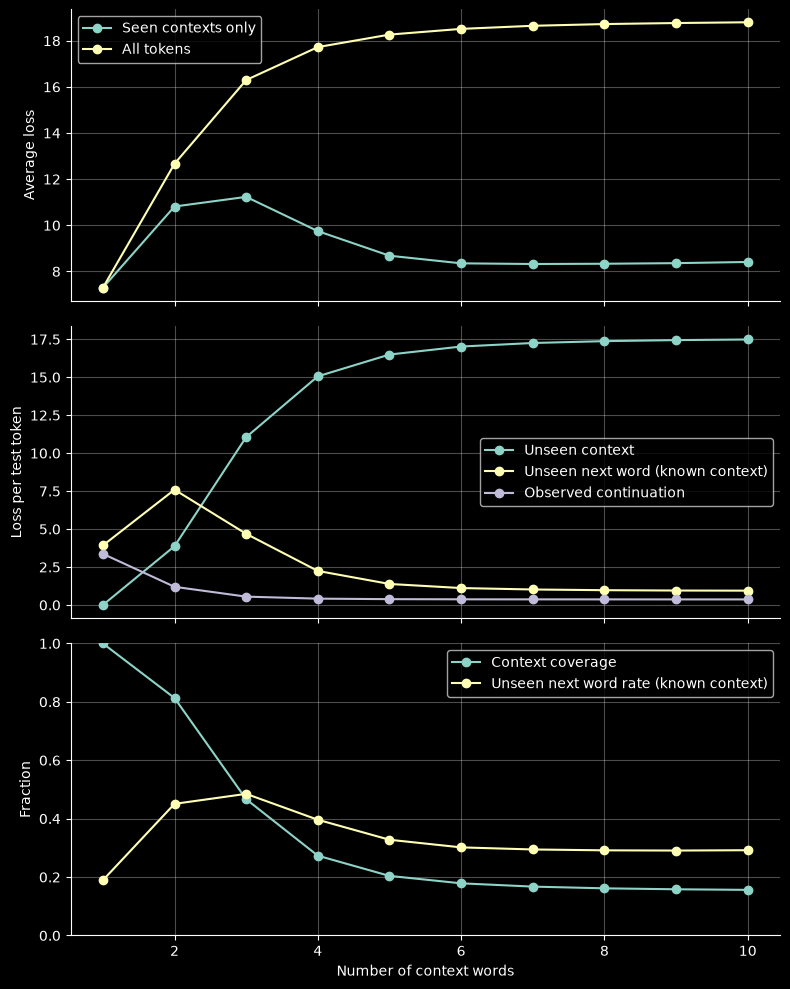

In [162]:
df = loss_at_n_total.set_index("n")
fig, axes = plt.subplots(3, 1, figsize=(8, 10), sharex=True)

df[["average_loss", "average_loss_punish"]].rename(columns={
    "average_loss": "Seen contexts only",
    "average_loss_punish": "All tokens",
}).plot(ax=axes[0], marker="o")
axes[0].set_ylabel("Average loss")

df[["unseen_context_loss_per_token", "unseen_target_loss_per_token",
    "observed_loss_per_token"]].rename(columns={
    "unseen_context_loss_per_token": "Unseen context",
    "unseen_target_loss_per_token": "Unseen next word (known context)",
    "observed_loss_per_token": "Observed continuation",
}).plot(ax=axes[1], marker="o")
axes[1].set_ylabel("Loss per test token")

df[["context_coverage", "unseen_target_rate_given_context"]].rename(columns={
    "context_coverage": "Context coverage",
    "unseen_target_rate_given_context": "Unseen next word rate (known context)",
}).plot(ax=axes[2], marker="o")
axes[2].set_ylabel("Fraction")
axes[2].set_ylim(0, 1)
axes[2].set_xlabel("Number of context words")

for ax in axes:
    ax.grid(alpha=0.3)
sns.despine()
plt.tight_layout()


The bigram model performs the best in "punished" and "naive" models. Furthermore there is a non-monotonic relationship between the number of context words and the average loss, which is surprising. I believe that this could likely be attributed to many things. 

The training set is too small and thus longer sequences can't generalise. The number of possible sequences grows exponentially. Consider the vocabulary set $\textbf{V} = \{v_1, v_2, \dots, v_M\}$ with vocabulary size $M$. For a sequence of length $S$, ignoring vocabulary rules etc., the number of possible sequences is $M^S$.

In [163]:
ngrams = range(1, 5)
model_pool = []
loss_at_n = []

# n is a (n + 1)-gram; n denoting the number of words to predict the next one
for n in ngrams:
    count = defaultdict(Counter)

    # open file and count
    with open("../data/penn-treebank/ptb.train.txt") as f:
        for line in f:
            word = line.strip().split()
            tokens = ["<s>" for _ in range(1, n+1)] + word + ["</s>"]

            for i in range(n, len(tokens)):
                count[tuple(tokens[i-n:i])][tokens[i]] += 1

    model_pool.append(count)

#### Backoff

We can use a "backoff" approach to enrich our next-word predictions. Given that with a training set size $\to \infty$, that all of our $n$-grams could generalise, then it would be plausible that we should always use the largest model possible. Backoff tries to use the longest sequence of words possible, and if there exists context, then this context is used. If the context does not exist, then the window is shrunk until the context exists in the model.

In [164]:
total_loss_backoff = 0
num_of_preds_backoff = 0

with open('../data/penn-treebank/ptb.test.txt') as f:
    for line in f:
        words = line.strip().split()
        tokens = ["<s>" for _ in range(1, 5)] + words + ["</s>"]

        for i in range(len(model_pool), len(tokens)):
            # back-off process, start with largest model
            for idx, model in enumerate(model_pool[::-1]):
                n = 4 - idx
                input_words = tokens[i-n:i]

                # check if input words exist otherwise wait
                if tuple(input_words) in model.keys():
                    total_loss_backoff += loss_at_n_tuples(model, tuple(input_words), tokens[i])
                    num_of_preds_backoff += 1


Unfortunately due to the limiting factors of the data set, the backoff approach is not better than the bigram model.

In [167]:
print(f'Average loss: {round(total_loss_backoff / num_of_preds_backoff, 3)}')

Average loss: 9.396
